# EX 5.3 : Supervised classification

This exercise will show an example of **binary, supervised classification**. Rather than trying to discriminate each of the five sleep stages as in the previous exercise, the problem is simplified into a binary classification problem: wake (label = 1) versus NREM sleep (label = 0). We will train a classifier using all available training data (features and labels). Then we will apply this classifier on a new unseen test set to measure the performance of the classifier.

## Background
In supervised classification, prior knowledge is used to construct mathematical models that describe the data and then, based on these models, estimate the class for new unlabeled data. Several algorithms are available to perform supervised classification. In order to decide which classification algorithm performs best, we need to evaluate their performance. Classifier performance evaluation requires to split the original data in a training set and a test set. The training set is used to build the classifier and the test set is used to evaluate the performance of the classifier. For now, we will use a seperate test set. In the next exercise session, we will introduce cross-validation methods, such as leave-one-patient-out, to perform this data splitting.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os
import sklearn

## 3.1 Data preparation

**Load the EEG features** from `feat_train.npy` and `feat_test.npy`. These numpy arrays have a similar structure as in exercise 1 (the feature matrices have the shape $𝑋\in\mathbb{R}^{𝑆\times 𝐹}$).

**Load the clinical annotations** (sleep stages) from `labels_train.npy` and `labels_test.npy`. There are only 2 labels in this exercise: wake (label = 1) versus NREM sleep (label = 0).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Biomedical Data Processing/new /EX5: Introduction to classification and pattern recognition"

sleep_path = os.path.join(base_path, "EEG_sleep")
sup_path   = os.path.join(base_path, "EEG_sleep_supervised")

print("EEG_SLEEP:", os.listdir(sleep_path))
print("EEG_SLEEP_SUPERVISED:", os.listdir(sup_path))

# features = np.load(os.path.join(sleep_path, "features.npy"))
# labels   = np.load(os.path.join(sleep_path, "labels.npy"))
# labels = np.squeeze(labels)

EEG_SLEEP: ['features.npy', 'labels.npy']
EEG_SLEEP_SUPERVISED: ['labels_test.npy', 'labels_train.npy', 'feat_test.npy', 'feat_train.npy']


In [5]:
# Load the features and labels
features_test = np.load(os.path.join(sup_path, 'feat_test.npy'))
features_train = np.load(os.path.join(sup_path, 'feat_train.npy'))
labels_test = np.load(os.path.join(sup_path, 'labels_test.npy'))
labels_train = np.load(os.path.join(sup_path, 'labels_train.npy'))
labels_test = np.squeeze(labels_test)
labels_train = np.squeeze(labels_train)

# features is a numpy array with shape (n_samples, n_features)
# labels is a numpy array with shape (n_samples,)

print("Features (train) shape:", features_train.shape)
print("Labels (train) shape:", labels_train.shape)

print("Features (test) shape:", features_test.shape)
print("Labels (test) shape:", labels_test.shape)

# Define the names of the features and the classes.
feature_names = ['Relative Delta power','Relative Theta power','Relative Alpha power','Relative Beta power']
sleep_stages = ['NREM', 'Wake']

Features (train) shape: (450, 4)
Labels (train) shape: (450,)
Features (test) shape: (697, 4)
Labels (test) shape: (697,)


In [8]:
df = pd.DataFrame(features_train, columns=feature_names)
print(df.describe())
idx = 0  # pick any index you want
print("Features for sample", idx, ":", features_train[idx])
print("Label for this sample:", labels_train[idx])
print("Interpreted as class:", sleep_stages[labels_train[idx]])

# Someone applied a windowing method (maybe 20–30 seconds of EEG), computed the power in standard frequency bands, normalized them, and stored them as features.

       Relative Delta power  Relative Theta power  Relative Alpha power  \
count            450.000000            450.000000            450.000000   
mean               0.522030              0.097204              0.086650   
std                0.205972              0.045207              0.033942   
min                0.128180              0.013142              0.009905   
25%                0.360318              0.064104              0.063339   
50%                0.502119              0.092137              0.085872   
75%                0.669107              0.126976              0.109283   
max                0.919534              0.304875              0.182208   

       Relative Beta power  
count           450.000000  
mean              0.294117  
std               0.190047  
min               0.012894  
25%               0.123882  
50%               0.285411  
75%               0.434047  
max               0.742067  
Features for sample 0 : [0.25512007 0.04274825 0.0551355  0.646

### Feature normalization

The data of the previous exercises were already normalized (mean 0 and standard deviation 1). For the new data, this is not the case (check this!). **Perform feature normalization** on the data.

In a classification task, it is of utmost importance to never have any piece of information about the test data slipping in the training procedure (‘information leakage’). This is because this could lead to overoptimistic results, when calculating the performance of the algorithm on the test data. Carefully consider which data you include for normalization, as to avoid information leakage. This is not trivial!

Some useful functions from the package *sklearn*:
- **preprocessing.StandardScaler**: perform z-score standardization
- **fit**: train a model on a dataset
- **transform**: transform the data using a trained model

In [ ]:
sklearn.preprocessing.StandardScaler?

In [9]:
# Perform feature normalization

scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(features_train)
features_train_norm = scaler.transform(features_train)
features_test_norm = scaler.transform(features_test)
print(scaler.mean_)
print(scaler.scale_)

[0.52202988 0.09720394 0.08664958 0.29411661]
[0.20574313 0.04515659 0.03390462 0.18983563]


## 3.2 Performance using new, unseen test data

### Train a classifier

**Train a Logistic Regression classifier** using all available training data.

Then **apply this classifier** on the unseen test set.

Some useful functions from the package *sklearn*:
- **linear_model.LogisticRegression**: perform Logistic Regression classification
- **fit**: train a model on a dataset
- **predict**: predict the classes using a trained model
- **predict_proba**: get the classification scores using a trained model (Hint: have a look at the output of this function. Do you need all of it?)

(Hint: What is the difference between `predict` and `predict_proba`?)


In [ ]:
sklearn.linear_model.LogisticRegression?

In [11]:
clf = sklearn.linear_model.LogisticRegression()
clf.fit(features_train_norm, labels_train)
predictions = clf.predict(features_test_norm)
proba_predictions = clf.predict_proba(features_test_norm)
clf.score(features_test_norm, labels_test)

0.5753228120516499

In [12]:
print("Predict:", predictions)
print("Predics proba", proba_predictions)

Predict: [0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0

### Define performance metrics

To measure the performance of the classifier, we need metrics. In this exercise, we will use accuracy, sensitivity, specificity and the area under the ROC curve (AUC).
**Define a function `measure_performance`** that calculates the first 3 metrics, given the predictions of the classifier and the ground truth labels.

A useful function from the package *numpy*:
- **logical_and**: Perform the element-wise AND operation between two arrays with truth values.

(Hint: There exist several methods in sklearn to calculate these metrics, but try to implement them yourself to really understand what is going on)

In [ ]:
np.logical_and

<ufunc 'logical_and'>

In [13]:
def measure_performance(class_label, true_label):
    # Compute the accuracy, sensitivity and specificity of the classifier

    # Accuracy = (True positives + True negatives) / Total number of samples
    # true positive -> predict 1, true 1
    # true negative -> predict 0, true 0
    # false positive -> predict 1, true 0
    # false negative -> predict 0, true 1
    # sensitivity (recall) = aka true positive rate = true positives / (True positives + False negatives)
    # specificity = TN / (TN + FP) # This measures the proportion of actual negatives that are correctly identified as such.

    TP = np.sum(np.logical_and(class_label == 1, true_label == 1))
    TN = np.sum(np.logical_and(class_label == 0, true_label == 0))
    FP = np.sum(np.logical_and(class_label == 1, true_label == 0))
    FN = np.sum(np.logical_and(class_label == 0, true_label == 1))

    acc = (TP + TN) / (TP + TN + FP + FN)
    sens = TP / (TP + FN)
    spec = TN / (TN + FP)

    return acc, sens, spec

### Calculate performance

**Do the following**:
- Calculate the area under the ROC curve (AUROC).
- Using the previously defined function `measure_performance`, assess the performance of the classifier by computing the accuracy, sensitivity, specificity.
- Report all performance measures in a table.
- Plot the ROC curve.
- Mark the point on the ROC curve that should be chosen if maximally 10% of the NREM epochs can be wrongly detected as awake. What is the corresponding sensitivity?


Some useful functions:
- from the package *sklearn.metrics*:
    - **roc_auc_score**: evaluate AUROC
    - **roc_curve**: construct ROC
- from the package *numpy*:
    - **argwhere**: get the indices of the elements in an array for which a certain condition holds





In [ ]:
sklearn.metrics.roc_curve?

AUROC: 0.7629477151090984
Best idx 46
Chosen threshold: 0.16573512855205805
FPR at this point: 0.0893371757925072
Sensitivity (TPR) at this point: 0.5885714285714285


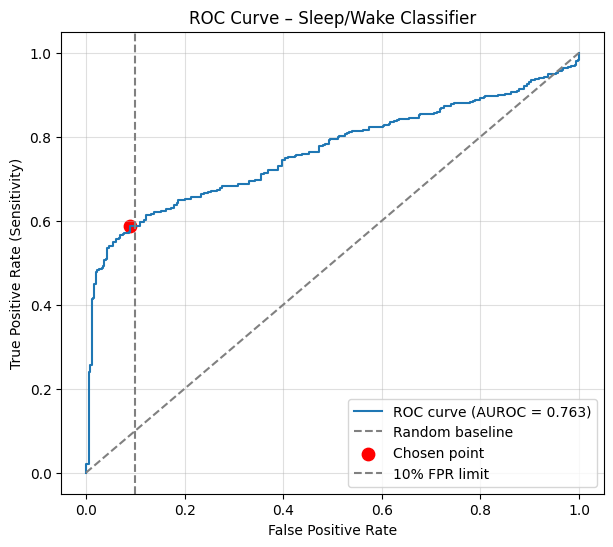

,Metric,Value
0,Accuracy,0.575323
1,Sensitivity,0.160000
2,Specificity,0.994236
3,AUROC,0.762948
4,Chosen Sensitivity,0.588571


In [15]:
# Make ROC curve & compute area under curve

# ...
fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels_test, proba_predictions[:, 1]) #pos_label=2??
auroc = sklearn.metrics.roc_auc_score(labels_test, proba_predictions[:, 1]) # binary case

print("AUROC:", auroc)

# Mark requested working point on ROC curve
# Find threshold where FPR ≤ 10%

# "maximally 10% of NREM epochs can be wrongly detected as awake"
# → NREM = negative class
# → false positive rate (FPR) must be ≤ 0.10

valid_indices = np.argwhere(fpr <= 0.10).flatten()

# index of best point (highest TPR among valid FPR)
best_idx = valid_indices[-1]
print("Best idx", best_idx)

fpr_at_point = fpr[best_idx]
tpr_at_point = tpr[best_idx]
threshold_at_point = thresholds[best_idx]

print("Chosen threshold:", threshold_at_point)
print("FPR at this point:", fpr_at_point)
print("Sensitivity (TPR) at this point:", tpr_at_point)

# In clinical terms: Sensitivity = probability of detecting “awake” correctly.

# Compute  AUC

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUROC = {auroc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')

# Mark the chosen working point
plt.scatter(fpr_at_point, tpr_at_point, color="red", s=80, label="Chosen point")

plt.axvline(0.10, color='gray', linestyle='--', label='10% FPR limit')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Sleep/Wake Classifier")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# Compute the metrics
acc, sens, spec = measure_performance(predictions, labels_test)


# Display the metric values in a table

results = pd.DataFrame({
    "Metric": ["Accuracy", "Sensitivity", "Specificity", "AUROC", "Chosen Sensitivity"],
    "Value": [acc, sens, spec, auroc, tpr_at_point]
})

results

### (Optional) Plot your own ROC

Use the `measure_performance` function to calculate and plot your own ROC. This should give the same results as the predefined function `roc_curve` from the package *sklearn*. Doing this will help you to better understand the ROC curve.

To calculate the area under the ROC curve (AUC), you can use `numpy.trapezoid` (hint: have a look at the order of the x-values, do they need to be increasing or decreasing?).

Manual AUC: 0.7626636475916014


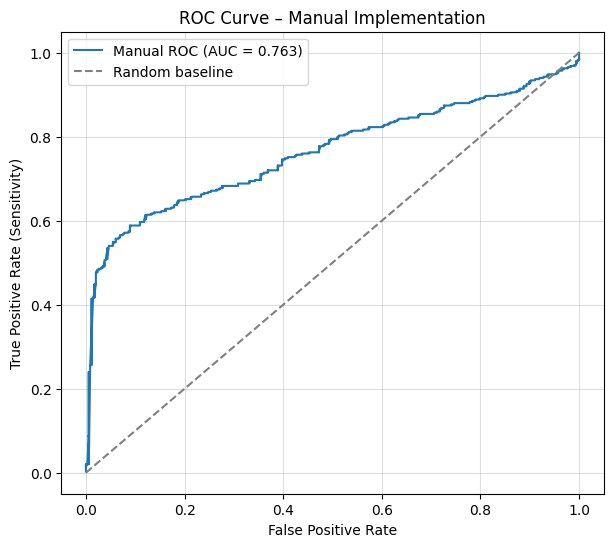

In [17]:
def compute_tpr_fpr(y_true, y_score, threshold):
    # Predict class 1 if probability >= threshold
    y_pred = (y_score >= threshold).astype(int)

    # Confusion matrix elements
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    # Avoid div by zero
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    return TPR, FPR


y_true = labels_test
y_score = proba_predictions[:, 1]   # probability of Wake

thresholds = np.sort(np.unique(y_score))  # increasing order

tprs = []
fprs = []

for th in thresholds:
    TPR, FPR = compute_tpr_fpr(y_true, y_score, th)
    tprs.append(TPR)
    fprs.append(FPR)


fprs = np.array(fprs)
tprs = np.array(tprs)

# Sort by FPR (ROC wants increasing FPR)
order = np.argsort(fprs)
fprs = fprs[order]
tprs = tprs[order]

auc_manual = np.trapezoid(tprs, fprs)
print("Manual AUC:", auc_manual)

plt.figure(figsize=(7, 6))
plt.plot(fprs, tprs, label=f"Manual ROC (AUC = {auc_manual:.3f})")

# Add baseline for intuition
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Manual Implementation")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

